# Nonuniform HSBM large-n scaling spectral clustering

This notebook generates non-uniform HSBM hypergraphs with `generate_nonuniform_hsbm_instance`, runs spectral clustering with the Zhou normalized hypergraph Laplacian, and records misclassification rate, ARI, NMI, CPU time, wall-clock time, and memory diagnostics as `n` increases.

Each experiment cell below runs a different node count. Edit `CONFIG` or add another `df_n... = run_n_experiment(...)` cell to extend the sweep.

In [1]:
from pathlib import Path
import gc
import json
import math
import sys
import time
import tracemalloc
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "src" / "common.py").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find project root containing src/common.py")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.common import (
    generate_nonuniform_hsbm_instance,
    make_sparse_hsbm_probs,
    normalize_rows_l2,
    zhou_normalized_laplacian,
)

EXPERIMENT_ID = "EXP-20260426-002"
EXPERIMENT_SLUG = "nonuniform_hsbm_large_n_1000_to_10000_zhou_laplacian"
OUTDIR = PROJECT_ROOT / "experiments" / "메인 실험" / "results" / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}"
OUTDIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

EXPERIMENT_ID, EXPERIMENT_SLUG, PROJECT_ROOT, OUTDIR

('EXP-20260426-002',
 'nonuniform_hsbm_large_n_1000_to_10000_zhou_laplacian',
 WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research'),
 WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/메인 실험/results/EXP-20260426-002_nonuniform_hsbm_large_n_1000_to_10000_zhou_laplacian'))

## Configuration

`make_sparse_hsbm_probs` maps the constant-scale parameters below to `p_in[m] = a_in[m] / n ** (m - 1)` and `p_out[m] = b_out[m] / n ** (m - 1)`. This keeps the expected number of hyperedges roughly linear in `n`.

In [2]:
CONFIG = {
    "K": 3,
    "m_values": [2, 3],
    "a_in": {2: 24.0, 3: 36.0},
    "b_out": {2: 3.0, 3: 4.0},
    "reps": 10,
    "seed": 20260425,
    "sampling": "sparse",
    "max_enumeration": 1_500_000,
    "normalize_embedding_rows": True,
    "eigsh_tol": 1e-6,
}

N_VALUES = list(range(1000, 10001, 1000))

CONFIG, N_VALUES

({'K': 3,
  'm_values': [2, 3],
  'a_in': {2: 24.0, 3: 36.0},
  'b_out': {2: 3.0, 3: 4.0},
  'reps': 10,
  'seed': 20260425,
  'sampling': 'sparse',
  'max_enumeration': 1500000,
  'normalize_embedding_rows': True,
  'eigsh_tol': 1e-06},
 [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000])

## Helpers

In [3]:
def current_rss_mb():
    try:
        import psutil

        return psutil.Process().memory_info().rss / (1024.0 ** 2)
    except Exception:
        return np.nan


def measure_call(fn):
    gc.collect()
    rss_before_mb = current_rss_mb()
    tracemalloc.start()
    cpu_start = time.process_time()
    wall_start = time.perf_counter()
    value = fn()
    wall_clock_sec = time.perf_counter() - wall_start
    cpu_time_sec = time.process_time() - cpu_start
    current_bytes, peak_bytes = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    rss_after_mb = current_rss_mb()
    return value, {
        "cpu_time_sec": float(cpu_time_sec),
        "wall_clock_sec": float(wall_clock_sec),
        "peak_traced_memory_mb": float(peak_bytes / (1024.0 ** 2)),
        "rss_before_mb": float(rss_before_mb) if np.isfinite(rss_before_mb) else np.nan,
        "rss_after_mb": float(rss_after_mb) if np.isfinite(rss_after_mb) else np.nan,
        "rss_delta_mb": float(rss_after_mb - rss_before_mb)
        if np.isfinite(rss_before_mb) and np.isfinite(rss_after_mb)
        else np.nan,
    }


def aligned_misclassification_rate(y_true, y_pred, K):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    conf = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true, y_pred):
        if 0 <= t < K and 0 <= p < K:
            conf[t, p] += 1
    true_ids, pred_ids = linear_sum_assignment(-conf)
    pred_to_true = {int(pred): int(true) for true, pred in zip(true_ids, pred_ids)}
    y_aligned = np.array([pred_to_true.get(int(p), int(p)) for p in y_pred], dtype=int)
    return float(np.mean(y_aligned != y_true)), y_aligned, conf


def hypergraph_vertex_degree_stats(n, hyperedges):
    degrees = np.zeros(int(n), dtype=float)
    for edge in hyperedges:
        for v in edge:
            degrees[int(v)] += 1.0
    return {
        "num_isolated_nodes": int(np.sum(degrees == 0)),
        "hypergraph_degree_mean": float(degrees.mean()) if n > 0 else 0.0,
        "hypergraph_degree_max": float(degrees.max()) if n > 0 else 0.0,
    }


def spectral_cluster_from_zhou_laplacian(L, K, rng, normalize_rows=True, eigsh_tol=1e-6):
    n = int(L.shape[0])
    L = ((L + L.T) * 0.5).tocsr()
    total_start = time.perf_counter()
    timings = {}

    t0 = time.perf_counter()
    if n <= K + 1:
        vals, vecs = np.linalg.eigh(L.toarray())
        order = np.argsort(vals)[:K]
        U = vecs[:, order]
    else:
        try:
            v0 = rng.normal(size=n)
            vals, vecs = spla.eigsh(L, k=K, which="SA", tol=eigsh_tol, v0=v0)
            order = np.argsort(vals)
            U = vecs[:, order]
        except Exception as exc:
            warnings.warn(f"eigsh failed ({exc}); falling back to dense eigh.")
            vals, vecs = np.linalg.eigh(L.toarray())
            order = np.argsort(vals)[:K]
            U = vecs[:, order]
    timings["eigen_decomposition_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    if normalize_rows:
        U = normalize_rows_l2(U)
    timings["embedding_normalize_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    random_state = int(rng.integers(1, 2**31 - 1))
    labels = KMeans(n_clusters=K, n_init=20, random_state=random_state).fit_predict(U)
    timings["kmeans_wall_sec"] = time.perf_counter() - t0
    timings["spectral_clustering_wall_sec"] = time.perf_counter() - total_start
    return labels, {
        "zhou_laplacian_nnz": int(L.nnz),
        **timings,
    }


def run_one_rep(n, rep, config):
    K = int(config["K"])
    m_values = [int(m) for m in config["m_values"]]
    seed = int(config["seed"] + 1_000_003 * int(n) + int(rep))
    rng = np.random.default_rng(seed)
    p_in, p_out = make_sparse_hsbm_probs(
        n=n,
        m_values=m_values,
        a_in=config["a_in"],
        b_out=config["b_out"],
    )

    timings = {}
    t0 = time.perf_counter()
    hyperedges, y_true, Theta_true, gen_stats = generate_nonuniform_hsbm_instance(
        n=n,
        K=K,
        m_values=m_values,
        p_in=p_in,
        p_out=p_out,
        rng=rng,
        sampling=config["sampling"],
        max_enumeration=int(config["max_enumeration"]),
    )
    timings["generation_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    L = zhou_normalized_laplacian(n=n, hyperedges=hyperedges)
    timings["zhou_laplacian_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred, spectral_stats = spectral_cluster_from_zhou_laplacian(
        L=L,
        K=K,
        rng=rng,
        normalize_rows=bool(config["normalize_embedding_rows"]),
        eigsh_tol=float(config["eigsh_tol"]),
    )
    timings["spectral_clustering_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    mis, y_aligned, conf = aligned_misclassification_rate(y_true, y_pred, K)
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    timings["metric_wall_sec"] = time.perf_counter() - t0

    record = {
        "n": int(n),
        "rep": int(rep),
        "seed": seed,
        "K": K,
        "m_values": ",".join(str(m) for m in m_values),
        "num_hyperedges_total": int(len(hyperedges)),
        "misclassification_rate": mis,
        "ARI": float(ari),
        "NMI": float(nmi),
        **timings,
        **hypergraph_vertex_degree_stats(n, hyperedges),
        **spectral_stats,
    }
    record["algorithm_total_wall_sec"] = float(
        record["generation_wall_sec"]
        + record["zhou_laplacian_wall_sec"]
        + record["eigen_decomposition_wall_sec"]
        + record["embedding_normalize_wall_sec"]
        + record["kmeans_wall_sec"]
    )

    per_size = gen_stats.get("per_size", {})
    for m in m_values:
        stats_m = per_size.get(str(m), {})
        record[f"p_in_m{m}"] = float(p_in[m])
        record[f"p_out_m{m}"] = float(p_out[m])
        record[f"num_edges_m{m}"] = int(stats_m.get("num_hyperedges", stats_m.get("num_edges", 0)))
        record[f"sampling_m{m}"] = stats_m.get("sampling_mode", "")

    return record


def run_one_rep_measured(n, rep, config):
    record, measurement = measure_call(lambda: run_one_rep(n, rep, config))
    record.update(measurement)
    return record


def run_n_experiment(n, reps=None, config=None):
    if config is None:
        config = CONFIG
    if reps is None:
        reps = int(config["reps"])

    rows = []
    for rep in range(1, reps + 1):
        row = run_one_rep_measured(n=n, rep=rep, config=config)
        rows.append(row)
        print(
            f"n={n:5d} rep={rep:2d}/{reps:<2d} "
            f"edges={row['num_hyperedges_total']:6d} "
            f"mis={row['misclassification_rate']:.4f} "
            f"ARI={row['ARI']:.4f} NMI={row['NMI']:.4f} "
            f"eig={row['eigen_decomposition_wall_sec']:.3f}s "
            f"km={row['kmeans_wall_sec']:.3f}s "
            f"wall={row['wall_clock_sec']:.3f}s "
            f"peak={row['peak_traced_memory_mb']:.1f}MB"
        )

    df = pd.DataFrame(rows)
    display(df)
    return df


def summarize_by_n(df_raw):
    return df_raw.groupby("n", as_index=False).agg(
        reps=("rep", "count"),
        hyperedges_mean=("num_hyperedges_total", "mean"),
        hyperedges_std=("num_hyperedges_total", "std"),
        misclassification_mean=("misclassification_rate", "mean"),
        misclassification_std=("misclassification_rate", "std"),
        ari_mean=("ARI", "mean"),
        ari_std=("ARI", "std"),
        nmi_mean=("NMI", "mean"),
        nmi_std=("NMI", "std"),
        generation_wall_sec_mean=("generation_wall_sec", "mean"),
        generation_wall_sec_std=("generation_wall_sec", "std"),
        zhou_laplacian_wall_sec_mean=("zhou_laplacian_wall_sec", "mean"),
        zhou_laplacian_wall_sec_std=("zhou_laplacian_wall_sec", "std"),
        eigen_decomposition_wall_sec_mean=("eigen_decomposition_wall_sec", "mean"),
        eigen_decomposition_wall_sec_std=("eigen_decomposition_wall_sec", "std"),
        embedding_normalize_wall_sec_mean=("embedding_normalize_wall_sec", "mean"),
        embedding_normalize_wall_sec_std=("embedding_normalize_wall_sec", "std"),
        kmeans_wall_sec_mean=("kmeans_wall_sec", "mean"),
        kmeans_wall_sec_std=("kmeans_wall_sec", "std"),
        spectral_clustering_wall_sec_mean=("spectral_clustering_wall_sec", "mean"),
        spectral_clustering_wall_sec_std=("spectral_clustering_wall_sec", "std"),
        metric_wall_sec_mean=("metric_wall_sec", "mean"),
        metric_wall_sec_std=("metric_wall_sec", "std"),
        algorithm_total_wall_sec_mean=("algorithm_total_wall_sec", "mean"),
        algorithm_total_wall_sec_std=("algorithm_total_wall_sec", "std"),
        cpu_time_sec_mean=("cpu_time_sec", "mean"),
        cpu_time_sec_std=("cpu_time_sec", "std"),
        wall_clock_sec_mean=("wall_clock_sec", "mean"),
        wall_clock_sec_std=("wall_clock_sec", "std"),
        peak_traced_memory_mb_mean=("peak_traced_memory_mb", "mean"),
        peak_traced_memory_mb_std=("peak_traced_memory_mb", "std"),
        rss_delta_mb_mean=("rss_delta_mb", "mean"),
        rss_delta_mb_std=("rss_delta_mb", "std"),
    )

## n = 1000

In [4]:
df_n1000 = run_n_experiment(1000)

n= 1000 rep= 1/10 edges=  6202 mis=0.0050 ARI=0.9850 NMI=0.9703 eig=0.010s km=1.746s wall=2.127s peak=1.9MB
n= 1000 rep= 2/10 edges=  6253 mis=0.0120 ARI=0.9643 NMI=0.9363 eig=0.007s km=0.049s wall=0.445s peak=1.8MB
n= 1000 rep= 3/10 edges=  6152 mis=0.0070 ARI=0.9791 NMI=0.9604 eig=0.007s km=0.048s wall=0.435s peak=1.8MB
n= 1000 rep= 4/10 edges=  6269 mis=0.0060 ARI=0.9821 NMI=0.9658 eig=0.007s km=0.049s wall=0.443s peak=1.8MB
n= 1000 rep= 5/10 edges=  6185 mis=0.0090 ARI=0.9732 NMI=0.9493 eig=0.008s km=0.048s wall=0.423s peak=1.8MB
n= 1000 rep= 6/10 edges=  6284 mis=0.0050 ARI=0.9850 NMI=0.9703 eig=0.007s km=0.059s wall=0.460s peak=1.8MB
n= 1000 rep= 7/10 edges=  6199 mis=0.0070 ARI=0.9791 NMI=0.9592 eig=0.007s km=0.054s wall=0.438s peak=1.8MB
n= 1000 rep= 8/10 edges=  6172 mis=0.0030 ARI=0.9910 NMI=0.9814 eig=0.007s km=0.049s wall=0.418s peak=1.8MB
n= 1000 rep= 9/10 edges=  6361 mis=0.0030 ARI=0.9910 NMI=0.9827 eig=0.007s km=0.048s wall=0.431s peak=1.9MB
n= 1000 rep=10/10 edges=  62

,n,rep,seed,K,m_values,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,p_in_m2,p_out_m2,num_edges_m2,sampling_m2,p_in_m3,p_out_m3,num_edges_m3,sampling_m3,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,1000,1,1020263426,3,"2,3",6202,0.005,0.985026,0.970279,0.311924,0.024458,1.756247,0.011393,0,13.624,28.0,18136,0.010261,0.000065,1.745913,2.092622,0.024,0.003,4982,sparse,0.000036,0.000004,1220,sparse,0.796875,2.127237,1.851057,202.328125,206.816406,4.488281
1,1000,2,1020263427,3,"2,3",6253,0.012,0.964307,0.936263,0.331336,0.020537,0.056706,0.009028,0,13.770,28.0,18400,0.007423,0.000075,0.049202,0.408573,0.024,0.003,4989,sparse,0.000036,0.000004,1264,sparse,0.687500,0.445458,1.835695,206.820312,207.484375,0.664062
2,1000,3,1020263428,3,"2,3",6152,0.007,0.979074,0.960417,0.323360,0.019963,0.055903,0.009774,0,13.544,28.0,18124,0.007404,0.000068,0.048427,0.399222,0.024,0.003,4912,sparse,0.000036,0.000004,1240,sparse,0.765625,0.434767,1.807852,207.484375,207.652344,0.167969
3,1000,4,1020263429,3,"2,3",6269,0.006,0.982072,0.965829,0.328084,0.023137,0.056266,0.008954,0,13.800,25.0,18372,0.007323,0.000074,0.048865,0.407482,0.024,0.003,5007,sparse,0.000036,0.000004,1262,sparse,0.718750,0.443428,1.839052,207.652344,207.667969,0.015625
4,1000,5,1020263430,3,"2,3",6185,0.009,0.973153,0.949305,0.312606,0.020582,0.056079,0.011980,0,13.658,30.0,18388,0.007555,0.000067,0.048452,0.389262,0.024,0.003,4897,sparse,0.000036,0.000004,1288,sparse,0.781250,0.423055,1.818933,207.667969,207.664062,-0.003906
5,1000,6,1020263431,3,"2,3",6284,0.005,0.985039,0.970283,0.318648,0.021233,0.066701,0.015012,0,13.873,27.0,18602,0.007151,0.000073,0.059471,0.406577,0.024,0.003,4979,sparse,0.000036,0.000004,1305,sparse,0.812500,0.460426,1.843757,207.664062,207.664062,0.000000
6,1000,7,1020263432,3,"2,3",6199,0.007,0.979087,0.959162,0.318010,0.020695,0.061437,0.011682,0,13.591,27.0,18042,0.007324,0.000076,0.054031,0.400136,0.024,0.003,5006,sparse,0.000036,0.000004,1193,sparse,0.812500,0.438117,1.813630,207.664062,207.980469,0.316406
7,1000,8,1020263433,3,"2,3",6172,0.003,0.991000,0.981407,0.307030,0.020537,0.056396,0.008891,0,13.608,26.0,18262,0.007449,0.000073,0.048869,0.383959,0.024,0.003,4908,sparse,0.000036,0.000004,1264,sparse,0.765625,0.417762,1.810779,207.980469,208.046875,0.066406
8,1000,9,1020263434,3,"2,3",6361,0.003,0.990991,0.982664,0.322491,0.020000,0.055420,0.008698,0,13.964,28.0,18534,0.007317,0.000075,0.048023,0.397906,0.024,0.003,5119,sparse,0.000036,0.000004,1242,sparse,0.718750,0.430572,1.860982,208.046875,208.210938,0.164062
9,1000,10,1020263435,3,"2,3",6239,0.007,0.979052,0.960883,0.313744,0.019605,0.056681,0.011392,0,13.759,26.0,18424,0.007758,0.000067,0.048851,0.390026,0.024,0.003,4958,sparse,0.000036,0.000004,1281,sparse,0.765625,0.430145,1.833082,208.210938,208.292969,0.082031


## n = 2000

In [5]:
df_n2000 = run_n_experiment(2000)

n= 2000 rep= 1/10 edges= 12319 mis=0.0065 ARI=0.9806 NMI=0.9618 eig=0.009s km=0.032s wall=0.741s peak=3.7MB
n= 2000 rep= 2/10 edges= 12496 mis=0.0015 ARI=0.9955 NMI=0.9898 eig=0.009s km=0.032s wall=0.781s peak=3.8MB
n= 2000 rep= 3/10 edges= 12416 mis=0.0075 ARI=0.9776 NMI=0.9560 eig=0.010s km=0.044s wall=0.809s peak=3.7MB
n= 2000 rep= 4/10 edges= 12287 mis=0.0085 ARI=0.9747 NMI=0.9518 eig=0.009s km=0.031s wall=0.760s peak=3.7MB
n= 2000 rep= 5/10 edges= 12500 mis=0.0060 ARI=0.9821 NMI=0.9633 eig=0.009s km=0.033s wall=0.769s peak=3.8MB
n= 2000 rep= 6/10 edges= 12505 mis=0.0065 ARI=0.9806 NMI=0.9605 eig=0.010s km=0.046s wall=0.846s peak=3.8MB
n= 2000 rep= 7/10 edges= 12536 mis=0.0055 ARI=0.9836 NMI=0.9658 eig=0.009s km=0.033s wall=0.821s peak=3.8MB
n= 2000 rep= 8/10 edges= 12574 mis=0.0075 ARI=0.9776 NMI=0.9565 eig=0.009s km=0.030s wall=0.761s peak=3.8MB
n= 2000 rep= 9/10 edges= 12457 mis=0.0070 ARI=0.9791 NMI=0.9605 eig=0.009s km=0.034s wall=0.763s peak=3.7MB
n= 2000 rep=10/10 edges= 125

,n,rep,seed,K,m_values,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,p_in_m2,p_out_m2,num_edges_m2,sampling_m2,p_in_m3,p_out_m3,num_edges_m3,sampling_m3,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,2000,1,2020266426,3,"2,3",12319,0.0065,0.980586,0.961782,0.603382,0.038190,0.040781,0.013984,0,13.5120,28.0,36012,0.009041,0.000092,0.031644,0.682348,0.012,0.0015,9933,sparse,0.000009,0.000001,2386,sparse,1.125000,0.741446,3.695194,208.664062,206.554688,-2.109375
1,2000,2,2020266427,3,"2,3",12496,0.0015,0.995500,0.989757,0.622990,0.038408,0.040922,0.016270,0,13.7385,26.0,36766,0.008651,0.000066,0.032200,0.702315,0.012,0.0015,10011,sparse,0.000009,0.000001,2485,sparse,1.312500,0.781308,3.752179,206.554688,211.191406,4.636719
2,2000,3,2020266428,3,"2,3",12416,0.0075,0.977619,0.955989,0.618421,0.040792,0.054516,0.022117,0,13.6810,31.0,36772,0.009993,0.000089,0.044427,0.713722,0.012,0.0015,9886,sparse,0.000009,0.000001,2530,sparse,1.468750,0.808725,3.734902,211.191406,211.015625,-0.175781
3,2000,4,2020266429,3,"2,3",12287,0.0085,0.974656,0.951802,0.612844,0.038456,0.040200,0.019487,0,13.4845,31.0,36006,0.009032,0.000073,0.031090,0.691495,0.012,0.0015,9892,sparse,0.000009,0.000001,2395,sparse,1.234375,0.759890,3.688296,211.015625,206.750000,-4.265625
4,2000,5,2020266430,3,"2,3",12500,0.0060,0.982061,0.963303,0.623560,0.037966,0.041592,0.016328,0,13.7685,29.0,36974,0.008942,0.000080,0.032565,0.703113,0.012,0.0015,9963,sparse,0.000009,0.000001,2537,sparse,1.234375,0.769205,3.762011,206.750000,211.933594,5.183594
5,2000,6,2020266431,3,"2,3",12505,0.0065,0.980577,0.960524,0.655952,0.047140,0.056439,0.020067,0,13.7745,30.0,37004,0.010045,0.000087,0.046301,0.759524,0.012,0.0015,9966,sparse,0.000009,0.000001,2539,sparse,1.437500,0.845804,3.762528,211.933594,212.464844,0.531250
6,2000,7,2020266432,3,"2,3",12536,0.0055,0.983553,0.965847,0.660515,0.043638,0.041671,0.013311,0,13.7950,28.0,36996,0.008607,0.000070,0.032990,0.745820,0.012,0.0015,10018,sparse,0.000009,0.000001,2518,sparse,1.250000,0.820571,3.771235,212.464844,212.019531,-0.445312
7,2000,8,2020266433,3,"2,3",12574,0.0075,0.977613,0.956460,0.615797,0.038083,0.039164,0.014969,0,13.8325,30.0,37048,0.008932,0.000083,0.030144,0.693040,0.012,0.0015,10057,sparse,0.000009,0.000001,2517,sparse,1.218750,0.760653,3.780083,212.019531,211.019531,-1.000000
8,2000,9,2020266434,3,"2,3",12457,0.0070,0.979083,0.960527,0.610736,0.037899,0.042763,0.016115,0,13.7240,28.0,36898,0.008731,0.000069,0.033959,0.691394,0.012,0.0015,9923,sparse,0.000009,0.000001,2534,sparse,1.218750,0.763384,3.747894,211.019531,212.695312,1.675781
9,2000,10,2020266435,3,"2,3",12528,0.0085,0.974646,0.950697,0.630440,0.039062,0.040286,0.013238,0,13.7815,28.0,36924,0.009079,0.000083,0.031119,0.709783,0.012,0.0015,10021,sparse,0.000009,0.000001,2507,sparse,1.140625,0.769384,3.764643,212.695312,212.914062,0.218750


## n = 3000

In [6]:
df_n3000 = run_n_experiment(3000)

n= 3000 rep= 1/10 edges= 18754 mis=0.0047 ARI=0.9860 NMI=0.9712 eig=0.011s km=0.036s wall=1.119s peak=5.7MB
n= 3000 rep= 2/10 edges= 18626 mis=0.0090 ARI=0.9732 NMI=0.9480 eig=0.011s km=0.032s wall=1.143s peak=5.6MB
n= 3000 rep= 3/10 edges= 18905 mis=0.0077 ARI=0.9772 NMI=0.9565 eig=0.010s km=0.033s wall=1.156s peak=5.7MB
n= 3000 rep= 4/10 edges= 19162 mis=0.0037 ARI=0.9890 NMI=0.9763 eig=0.011s km=0.033s wall=1.167s peak=5.8MB
n= 3000 rep= 5/10 edges= 18698 mis=0.0047 ARI=0.9860 NMI=0.9704 eig=0.010s km=0.034s wall=1.151s peak=5.7MB
n= 3000 rep= 6/10 edges= 18646 mis=0.0047 ARI=0.9860 NMI=0.9711 eig=0.011s km=0.044s wall=1.159s peak=5.7MB
n= 3000 rep= 7/10 edges= 18687 mis=0.0100 ARI=0.9702 NMI=0.9434 eig=0.011s km=0.052s wall=1.218s peak=5.7MB
n= 3000 rep= 8/10 edges= 18827 mis=0.0070 ARI=0.9791 NMI=0.9590 eig=0.011s km=0.045s wall=1.367s peak=5.7MB
n= 3000 rep= 9/10 edges= 18727 mis=0.0083 ARI=0.9751 NMI=0.9514 eig=0.010s km=0.034s wall=1.209s peak=5.7MB
n= 3000 rep=10/10 edges= 186

,n,rep,seed,K,m_values,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,p_in_m2,p_out_m2,num_edges_m2,sampling_m2,p_in_m3,p_out_m3,num_edges_m3,sampling_m3,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,3000,1,3020269426,3,"2,3",18754,0.004667,0.986039,0.971203,0.910148,0.060780,0.046712,0.020837,0,13.749333,33.0,55314,0.010807,0.000079,0.035821,1.017635,0.008,0.001,15014,sparse,0.000004,4.444444e-07,3740,sparse,1.734375,1.119112,5.675196,212.925781,210.195312,-2.730469
1,3000,2,3020269427,3,"2,3",18626,0.009000,0.973171,0.947954,0.945689,0.060722,0.042693,0.020108,0,13.655333,29.0,54918,0.010828,0.000076,0.031785,1.049100,0.008,0.001,14912,sparse,0.000004,4.444444e-07,3714,sparse,1.765625,1.142683,5.644163,210.195312,210.164062,-0.031250
2,3000,3,3020269428,3,"2,3",18905,0.007667,0.977153,0.956549,0.958268,0.059953,0.043508,0.017570,0,13.858667,27.0,55702,0.010229,0.000072,0.033204,1.061725,0.008,0.001,15139,sparse,0.000004,4.444444e-07,3766,sparse,1.703125,1.155919,5.722439,210.164062,210.531250,0.367188
3,3000,4,3020269429,3,"2,3",19162,0.003667,0.989020,0.976294,0.953159,0.060574,0.043704,0.017692,0,14.068333,30.0,56668,0.011064,0.000076,0.032559,1.057432,0.008,0.001,15281,sparse,0.000004,4.444444e-07,3881,sparse,1.718750,1.167126,5.807906,210.531250,210.152344,-0.378906
4,3000,5,3020269430,3,"2,3",18698,0.004667,0.986041,0.970363,0.942483,0.059865,0.044219,0.020532,0,13.691333,30.0,54950,0.010321,0.000084,0.033810,1.046562,0.008,0.001,15020,sparse,0.000004,4.444444e-07,3678,sparse,1.828125,1.151259,5.661459,210.152344,210.355469,0.203125
5,3000,6,3020269431,3,"2,3",18646,0.004667,0.986049,0.971124,0.929669,0.059182,0.054526,0.022252,0,13.699000,38.0,55354,0.010915,0.000095,0.043511,1.043371,0.008,0.001,14841,sparse,0.000004,4.444444e-07,3805,sparse,1.796875,1.159481,5.660180,210.355469,210.558594,0.203125
6,3000,7,3020269432,3,"2,3",18687,0.010000,0.970220,0.943381,0.975647,0.064755,0.062693,0.030359,0,13.732333,27.0,55502,0.010715,0.000124,0.051849,1.103089,0.008,0.001,14864,sparse,0.000004,4.444444e-07,3823,sparse,1.859375,1.218153,5.672677,210.558594,210.429688,-0.128906
7,3000,8,3020269433,3,"2,3",18827,0.007000,0.979110,0.959031,1.107993,0.064941,0.055643,0.032077,0,13.822333,34.0,55730,0.010976,0.000107,0.044554,1.228571,0.008,0.001,15014,sparse,0.000004,4.444444e-07,3813,sparse,1.875000,1.366708,5.711792,210.429688,210.414062,-0.015625
8,3000,9,3020269434,3,"2,3",18727,0.008333,0.975141,0.951407,0.990077,0.059566,0.043998,0.018156,0,13.738667,28.0,55332,0.010040,0.000084,0.033869,1.093636,0.008,0.001,14965,sparse,0.000004,4.444444e-07,3762,sparse,1.750000,1.208667,5.677751,210.414062,210.425781,0.011719
9,3000,10,3020269435,3,"2,3",18662,0.011333,0.966261,0.937587,0.959126,0.059677,0.044060,0.017673,0,13.701667,29.0,55276,0.010041,0.000086,0.033928,1.062858,0.008,0.001,14881,sparse,0.000004,4.444444e-07,3781,sparse,1.609375,1.174518,5.662029,210.425781,210.425781,0.000000


## n = 4000

In [7]:
df_n4000 = run_n_experiment(4000)

n= 4000 rep= 1/10 edges= 25018 mis=0.0057 ARI=0.9828 NMI=0.9648 eig=0.012s km=0.044s wall=1.540s peak=7.6MB
n= 4000 rep= 2/10 edges= 25192 mis=0.0063 ARI=0.9813 NMI=0.9622 eig=0.012s km=0.037s wall=1.556s peak=7.7MB
n= 4000 rep= 3/10 edges= 25062 mis=0.0060 ARI=0.9821 NMI=0.9629 eig=0.012s km=0.040s wall=1.532s peak=7.6MB
n= 4000 rep= 4/10 edges= 25018 mis=0.0067 ARI=0.9798 NMI=0.9594 eig=0.012s km=0.039s wall=1.496s peak=7.6MB
n= 4000 rep= 5/10 edges= 25058 mis=0.0063 ARI=0.9813 NMI=0.9625 eig=0.012s km=0.037s wall=1.498s peak=7.6MB
n= 4000 rep= 6/10 edges= 24846 mis=0.0057 ARI=0.9828 NMI=0.9651 eig=0.013s km=0.042s wall=1.518s peak=7.6MB
n= 4000 rep= 7/10 edges= 25231 mis=0.0057 ARI=0.9828 NMI=0.9653 eig=0.012s km=0.038s wall=1.538s peak=7.7MB
n= 4000 rep= 8/10 edges= 25090 mis=0.0090 ARI=0.9732 NMI=0.9478 eig=0.012s km=0.036s wall=1.539s peak=7.6MB
n= 4000 rep= 9/10 edges= 24921 mis=0.0053 ARI=0.9843 NMI=0.9674 eig=0.012s km=0.043s wall=1.514s peak=7.6MB
n= 4000 rep=10/10 edges= 250

,n,rep,seed,K,m_values,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,p_in_m2,p_out_m2,num_edges_m2,sampling_m2,p_in_m3,p_out_m3,num_edges_m3,sampling_m3,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,4000,1,4020272426,3,"2,3",25018,0.00575,0.982819,0.964775,1.260186,0.076928,0.056258,0.036522,0,13.75325,27.0,73776,0.011678,0.000077,0.044496,1.393365,0.006,0.00075,20041,sparse,0.000002,2.500000e-07,4977,sparse,2.109375,1.540250,7.602339,210.492188,213.992188,3.500000
1,4000,2,4020272427,3,"2,3",25192,0.00625,0.981338,0.962224,1.303885,0.076038,0.048950,0.027566,0,13.88325,32.0,74818,0.011793,0.000077,0.037075,1.428867,0.006,0.00075,20043,sparse,0.000002,2.500000e-07,5149,sparse,2.093750,1.555528,7.673591,213.992188,214.042969,0.050781
2,4000,3,4020272428,3,"2,3",25062,0.00600,0.982074,0.962944,1.252314,0.073941,0.051479,0.025001,0,13.78125,28.0,73962,0.011845,0.000077,0.039552,1.377729,0.006,0.00075,20061,sparse,0.000002,2.500000e-07,5001,sparse,2.234375,1.532300,7.622466,214.042969,213.578125,-0.464844
3,4000,4,4020272429,3,"2,3",25018,0.00675,0.979843,0.959370,1.244427,0.074937,0.051309,0.025179,0,13.77025,28.0,74042,0.011820,0.000080,0.039404,1.370668,0.006,0.00075,19973,sparse,0.000002,2.500000e-07,5045,sparse,2.140625,1.495887,7.615966,213.578125,213.917969,0.339844
4,4000,5,4020272430,3,"2,3",25058,0.00625,0.981326,0.962519,1.243726,0.076216,0.048698,0.025250,0,13.79525,27.0,74210,0.011792,0.000097,0.036803,1.368635,0.006,0.00075,19993,sparse,0.000002,2.500000e-07,5065,sparse,2.093750,1.498229,7.631003,213.917969,213.992188,0.074219
5,4000,6,4020272431,3,"2,3",24846,0.00575,0.982819,0.965106,1.244312,0.085668,0.055382,0.029128,0,13.69500,29.0,73906,0.013324,0.000087,0.041964,1.385355,0.006,0.00075,19758,sparse,0.000002,2.500000e-07,5088,sparse,2.078125,1.518408,7.575445,213.992188,214.089844,0.097656
6,4000,7,4020272432,3,"2,3",25231,0.00575,0.982827,0.965327,1.274660,0.077229,0.049332,0.031155,0,13.87975,27.0,74540,0.011708,0.000080,0.037539,1.401216,0.006,0.00075,20174,sparse,0.000002,2.500000e-07,5057,sparse,2.140625,1.538362,7.673620,214.089844,214.292969,0.203125
7,4000,8,4020272433,3,"2,3",25090,0.00900,0.973171,0.947840,1.266587,0.075425,0.047990,0.023722,0,13.80375,29.0,74176,0.011740,0.000087,0.036157,1.389995,0.006,0.00075,20055,sparse,0.000002,2.500000e-07,5035,sparse,2.015625,1.538502,7.635085,214.292969,214.136719,-0.156250
8,4000,9,4020272434,3,"2,3",24921,0.00525,0.984310,0.967351,1.246923,0.079372,0.054838,0.024078,0,13.72750,30.0,73924,0.011778,0.000083,0.042971,1.381127,0.006,0.00075,19853,sparse,0.000002,2.500000e-07,5068,sparse,2.078125,1.513999,7.594896,214.136719,214.078125,-0.058594
9,4000,10,4020272435,3,"2,3",25091,0.00425,0.987283,0.972777,1.248363,0.076112,0.048124,0.025402,0,13.80400,27.0,74130,0.011735,0.000099,0.036284,1.372593,0.006,0.00075,20057,sparse,0.000002,2.500000e-07,5034,sparse,2.125000,1.498621,7.635477,214.078125,213.945312,-0.132812


## n = 5000

In [8]:
df_n5000 = run_n_experiment(5000)

n= 5000 rep= 1/10 edges= 31388 mis=0.0058 ARI=0.9827 NMI=0.9643 eig=0.015s km=0.046s wall=1.855s peak=9.6MB
n= 5000 rep= 2/10 edges= 31344 mis=0.0050 ARI=0.9851 NMI=0.9692 eig=0.013s km=0.038s wall=1.923s peak=9.6MB
n= 5000 rep= 3/10 edges= 31366 mis=0.0040 ARI=0.9880 NMI=0.9743 eig=0.014s km=0.053s wall=1.914s peak=9.6MB
n= 5000 rep= 4/10 edges= 31155 mis=0.0058 ARI=0.9827 NMI=0.9645 eig=0.013s km=0.044s wall=1.823s peak=9.5MB
n= 5000 rep= 5/10 edges= 31311 mis=0.0066 ARI=0.9803 NMI=0.9604 eig=0.013s km=0.038s wall=1.878s peak=9.5MB
n= 5000 rep= 6/10 edges= 31303 mis=0.0080 ARI=0.9761 NMI=0.9528 eig=0.014s km=0.039s wall=1.855s peak=9.5MB
n= 5000 rep= 7/10 edges= 31294 mis=0.0052 ARI=0.9845 NMI=0.9677 eig=0.014s km=0.036s wall=1.882s peak=9.6MB
n= 5000 rep= 8/10 edges= 31477 mis=0.0052 ARI=0.9845 NMI=0.9675 eig=0.013s km=0.039s wall=1.882s peak=9.6MB
n= 5000 rep= 9/10 edges= 31294 mis=0.0074 ARI=0.9779 NMI=0.9561 eig=0.013s km=0.037s wall=1.864s peak=9.6MB
n= 5000 rep=10/10 edges= 312

,n,rep,seed,K,m_values,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,p_in_m2,p_out_m2,num_edges_m2,sampling_m2,p_in_m3,p_out_m3,num_edges_m3,sampling_m3,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,5000,1,5020275426,3,"2,3",31388,0.0058,0.982676,0.964299,1.533816,0.104066,0.060940,0.026543,0,13.8074,30.0,92654,0.014973,0.000095,0.045866,1.698816,0.0048,0.0006,25127,sparse,0.000001,1.600000e-07,6261,sparse,2.562500,1.855096,9.570851,214.015625,212.511719,-1.503906
1,5000,2,5020275427,3,"2,3",31344,0.0050,0.985057,0.969214,1.613285,0.093965,0.051235,0.029178,0,13.7842,29.0,92472,0.013180,0.000091,0.037958,1.758479,0.0048,0.0006,25111,sparse,0.000001,1.600000e-07,6233,sparse,2.468750,1.922816,9.554239,212.511719,212.808594,0.296875
2,5000,3,5020275428,3,"2,3",31366,0.0040,0.988032,0.974350,1.570695,0.094680,0.066838,0.046908,0,13.8232,31.0,93100,0.013984,0.000105,0.052742,1.732206,0.0048,0.0006,24982,sparse,0.000001,1.600000e-07,6384,sparse,2.500000,1.914303,9.575973,212.808594,212.761719,-0.046875
3,5000,4,5020275429,3,"2,3",31155,0.0058,0.982669,0.964453,1.528318,0.092642,0.056996,0.029390,0,13.7170,32.0,92248,0.013097,0.000102,0.043790,1.677950,0.0048,0.0006,24880,sparse,0.000001,1.600000e-07,6275,sparse,2.515625,1.823437,9.508924,212.761719,212.722656,-0.039062
4,5000,5,5020275430,3,"2,3",31311,0.0066,0.980301,0.960396,1.566720,0.092441,0.051039,0.032603,0,13.7732,29.0,92436,0.013340,0.000105,0.037587,1.710193,0.0048,0.0006,25067,sparse,0.000001,1.600000e-07,6244,sparse,2.500000,1.877781,9.547735,212.722656,212.464844,-0.257812
5,5000,6,5020275431,3,"2,3",31303,0.0080,0.976138,0.952790,1.546362,0.098555,0.052806,0.034318,0,13.7776,30.0,92588,0.014120,0.000093,0.038584,1.697715,0.0048,0.0006,25021,sparse,0.000001,1.600000e-07,6282,sparse,2.453125,1.854846,9.547570,212.464844,212.792969,0.328125
6,5000,7,5020275432,3,"2,3",31294,0.0052,0.984456,0.967691,1.566735,0.094095,0.050047,0.029785,0,13.8090,31.0,93248,0.013760,0.000086,0.036196,1.710872,0.0048,0.0006,24837,sparse,0.000001,1.600000e-07,6457,sparse,2.484375,1.881714,9.567900,212.792969,212.753906,-0.039062
7,5000,8,5020275433,3,"2,3",31477,0.0052,0.984457,0.967473,1.568913,0.098689,0.052480,0.034567,0,13.8428,28.0,92840,0.013350,0.000148,0.038974,1.720073,0.0048,0.0006,25217,sparse,0.000001,1.600000e-07,6260,sparse,2.484375,1.882469,9.590237,212.753906,212.820312,0.066406
8,5000,9,5020275434,3,"2,3",31294,0.0074,0.977924,0.956116,1.557315,0.094464,0.049732,0.036126,0,13.7968,29.0,93010,0.012854,0.000099,0.036772,1.701505,0.0048,0.0006,24898,sparse,0.000001,1.600000e-07,6396,sparse,2.421875,1.864192,9.560475,212.820312,212.824219,0.003906
9,5000,10,5020275435,3,"2,3",31246,0.0042,0.987437,0.973025,1.595505,0.095635,0.052143,0.031996,0,13.7640,36.0,92612,0.013252,0.000106,0.038778,1.743276,0.0048,0.0006,24918,sparse,0.000001,1.600000e-07,6328,sparse,2.484375,1.902383,9.541278,212.824219,212.832031,0.007812


## n = 6000

In [9]:
df_n6000 = run_n_experiment(6000)

n= 6000 rep= 1/10 edges= 37330 mis=0.0067 ARI=0.9801 NMI=0.9600 eig=0.015s km=0.045s wall=2.183s peak=11.4MB
n= 6000 rep= 2/10 edges= 37538 mis=0.0073 ARI=0.9781 NMI=0.9563 eig=0.015s km=0.039s wall=2.306s peak=11.5MB
n= 6000 rep= 3/10 edges= 37814 mis=0.0057 ARI=0.9831 NMI=0.9648 eig=0.015s km=0.042s wall=2.283s peak=11.6MB
n= 6000 rep= 4/10 edges= 37417 mis=0.0060 ARI=0.9821 NMI=0.9635 eig=0.015s km=0.042s wall=2.212s peak=11.4MB
n= 6000 rep= 5/10 edges= 37440 mis=0.0057 ARI=0.9831 NMI=0.9656 eig=0.015s km=0.050s wall=2.269s peak=11.4MB
n= 6000 rep= 6/10 edges= 37598 mis=0.0070 ARI=0.9791 NMI=0.9582 eig=0.015s km=0.042s wall=2.315s peak=11.5MB
n= 6000 rep= 7/10 edges= 37550 mis=0.0060 ARI=0.9821 NMI=0.9631 eig=0.015s km=0.040s wall=2.242s peak=11.5MB
n= 6000 rep= 8/10 edges= 37542 mis=0.0072 ARI=0.9786 NMI=0.9570 eig=0.015s km=0.044s wall=2.287s peak=11.5MB
n= 6000 rep= 9/10 edges= 37651 mis=0.0057 ARI=0.9831 NMI=0.9648 eig=0.015s km=0.049s wall=2.255s peak=11.5MB
n= 6000 rep=10/10 e

,n,rep,seed,K,m_values,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,p_in_m2,p_out_m2,num_edges_m2,sampling_m2,p_in_m3,p_out_m3,num_edges_m3,sampling_m3,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,6000,1,6020278426,3,"2,3",37330,0.006667,0.980089,0.960037,1.803577,0.121167,0.060135,0.038450,0,13.685667,28.0,110326,0.015455,0.000106,0.044569,1.984874,0.004,0.0005,29876,sparse,0.000001,1.111111e-07,7454,sparse,2.750000,2.183063,11.402636,212.886719,216.042969,3.156250
1,6000,2,6020278427,3,"2,3",37538,0.007333,0.978120,0.956308,1.942214,0.120776,0.054149,0.034365,0,13.771833,29.0,111136,0.015159,0.000100,0.038884,2.117134,0.004,0.0005,29983,sparse,0.000001,1.111111e-07,7555,sparse,2.859375,2.306066,11.469727,216.046875,216.113281,0.066406
2,6000,3,6020278428,3,"2,3",37814,0.005667,0.983069,0.964816,1.918593,0.119283,0.056576,0.037723,0,13.898167,31.0,112498,0.014967,0.000093,0.041511,2.094446,0.004,0.0005,30053,sparse,0.000001,1.111111e-07,7761,sparse,2.859375,2.283300,11.570124,216.113281,216.171875,0.058594
3,6000,4,6020278429,3,"2,3",37417,0.006000,0.982079,0.963467,1.853846,0.116886,0.056594,0.035845,0,13.709167,30.0,110366,0.014661,0.000093,0.041835,2.027320,0.004,0.0005,29996,sparse,0.000001,1.111111e-07,7421,sparse,2.765625,2.211714,11.423095,216.171875,216.101562,-0.070312
4,6000,5,6020278430,3,"2,3",37440,0.005667,0.983063,0.965636,1.858707,0.125460,0.065273,0.039959,0,13.694167,29.0,109868,0.014960,0.000107,0.050201,2.049434,0.004,0.0005,30155,sparse,0.000001,1.111111e-07,7285,sparse,2.875000,2.269160,11.414187,216.101562,215.214844,-0.886719
5,6000,6,6020278431,3,"2,3",37598,0.007000,0.979110,0.958207,1.950662,0.118372,0.057078,0.031053,0,13.778167,31.0,110954,0.015095,0.000178,0.041798,2.126105,0.004,0.0005,30125,sparse,0.000001,1.111111e-07,7473,sparse,2.937500,2.314692,11.473392,215.214844,216.136719,0.921875
6,6000,7,6020278432,3,"2,3",37550,0.006000,0.982077,0.963073,1.880387,0.117994,0.055027,0.030227,0,13.780667,31.0,111258,0.014714,0.000112,0.040195,2.053402,0.004,0.0005,29966,sparse,0.000001,1.111111e-07,7584,sparse,2.937500,2.241630,11.478769,216.136719,216.144531,0.007812
7,6000,8,6020278433,3,"2,3",37542,0.007167,0.978610,0.956965,1.879229,0.135180,0.058419,0.036302,0,13.756333,27.0,110734,0.014783,0.000094,0.043535,2.072821,0.004,0.0005,30088,sparse,0.000001,1.111111e-07,7454,sparse,2.875000,2.287166,11.460947,216.144531,216.304688,0.160156
8,6000,9,6020278434,3,"2,3",37651,0.005667,0.983067,0.964775,1.867183,0.117430,0.064048,0.050503,0,13.811333,31.0,111374,0.015259,0.000102,0.048679,2.048652,0.004,0.0005,30085,sparse,0.000001,1.111111e-07,7566,sparse,2.812500,2.255317,11.502132,216.304688,215.472656,-0.832031
9,6000,10,6020278435,3,"2,3",37335,0.008667,0.974162,0.949504,1.855431,0.127037,0.064162,0.036462,0,13.687833,29.0,110338,0.016035,0.000107,0.048015,2.046625,0.004,0.0005,29878,sparse,0.000001,1.111111e-07,7457,sparse,2.937500,2.232929,11.404667,215.472656,215.402344,-0.070312


## n = 7000

In [10]:
df_n7000 = run_n_experiment(7000)

n= 7000 rep= 1/10 edges= 43140 mis=0.0077 ARI=0.9770 NMI=0.9545 eig=0.017s km=0.043s wall=2.474s peak=13.2MB
n= 7000 rep= 2/10 edges= 43712 mis=0.0046 ARI=0.9863 NMI=0.9707 eig=0.016s km=0.042s wall=2.532s peak=13.4MB
n= 7000 rep= 3/10 edges= 43798 mis=0.0071 ARI=0.9787 NMI=0.9571 eig=0.017s km=0.055s wall=2.593s peak=13.4MB
n= 7000 rep= 4/10 edges= 44178 mis=0.0067 ARI=0.9800 NMI=0.9591 eig=0.016s km=0.041s wall=2.626s peak=13.5MB
n= 7000 rep= 5/10 edges= 43749 mis=0.0056 ARI=0.9833 NMI=0.9657 eig=0.016s km=0.046s wall=2.601s peak=13.4MB
n= 7000 rep= 6/10 edges= 43942 mis=0.0056 ARI=0.9834 NMI=0.9653 eig=0.016s km=0.042s wall=2.577s peak=13.4MB
n= 7000 rep= 7/10 edges= 43653 mis=0.0067 ARI=0.9800 NMI=0.9600 eig=0.016s km=0.043s wall=2.524s peak=13.4MB
n= 7000 rep= 8/10 edges= 44155 mis=0.0061 ARI=0.9816 NMI=0.9624 eig=0.016s km=0.048s wall=2.580s peak=13.5MB
n= 7000 rep= 9/10 edges= 43979 mis=0.0061 ARI=0.9817 NMI=0.9623 eig=0.017s km=0.041s wall=2.568s peak=13.4MB
n= 7000 rep=10/10 e

,n,rep,seed,K,m_values,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,p_in_m2,p_out_m2,num_edges_m2,sampling_m2,p_in_m3,p_out_m3,num_edges_m3,sampling_m3,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,7000,1,7020281426,3,"2,3",43140,0.007714,0.976985,0.954455,2.050789,0.131796,0.059543,0.043318,0,13.569000,31.0,127944,0.016600,0.000112,0.042825,2.242122,0.003429,0.000429,34437,sparse,7.346939e-07,8.163265e-08,8703,sparse,2.968750,2.473761,13.208880,215.457031,212.980469,-2.476562
1,7000,2,7020281427,3,"2,3",43712,0.004571,0.986330,0.970656,2.136628,0.130017,0.057972,0.037502,0,13.749286,30.0,129536,0.016157,0.000207,0.041601,2.324610,0.003429,0.000429,34891,sparse,7.346939e-07,8.163265e-08,8821,sparse,3.171875,2.532081,13.377737,212.980469,216.269531,3.289062
2,7000,3,7020281428,3,"2,3",43798,0.007143,0.978679,0.957076,2.169638,0.138505,0.072552,0.039311,0,13.767714,31.0,129562,0.017361,0.000183,0.055001,2.380689,0.003429,0.000429,35020,sparse,7.346939e-07,8.163265e-08,8778,sparse,3.125000,2.592720,13.393282,216.269531,216.066406,-0.203125
3,7000,4,7020281429,3,"2,3",44178,0.006714,0.979953,0.959117,2.211404,0.136674,0.057676,0.034389,0,13.889429,29.0,130688,0.016090,0.000126,0.041455,2.405748,0.003429,0.000429,35308,sparse,7.346939e-07,8.163265e-08,8870,sparse,3.265625,2.625703,13.509730,216.066406,215.476562,-0.589844
4,7000,5,7020281430,3,"2,3",43749,0.005571,0.983349,0.965671,2.170015,0.128896,0.062036,0.042082,0,13.761000,30.0,129622,0.015937,0.000114,0.045979,2.360940,0.003429,0.000429,34920,sparse,7.346939e-07,8.163265e-08,8829,sparse,3.250000,2.601318,13.388239,215.476562,218.769531,3.292969
5,7000,6,7020281431,3,"2,3",43942,0.005571,0.983351,0.965267,2.195753,0.126963,0.058219,0.037750,0,13.819571,29.0,130146,0.016497,0.000173,0.041542,2.380929,0.003429,0.000429,35089,sparse,7.346939e-07,8.163265e-08,8853,sparse,3.218750,2.576826,13.442269,218.769531,217.617188,-1.152344
6,7000,7,7020281432,3,"2,3",43653,0.006714,0.979965,0.959971,2.132430,0.130851,0.058679,0.034969,0,13.725286,31.0,129230,0.015580,0.000098,0.042996,2.321955,0.003429,0.000429,34882,sparse,7.346939e-07,8.163265e-08,8771,sparse,3.140625,2.523774,13.355514,217.617188,217.910156,0.292969
7,7000,8,7020281433,3,"2,3",44155,0.006143,0.981650,0.962426,2.155415,0.130418,0.064491,0.057524,0,13.882857,28.0,130602,0.015966,0.000189,0.048329,2.350317,0.003429,0.000429,35285,sparse,7.346939e-07,8.163265e-08,8870,sparse,3.218750,2.579615,13.499675,217.910156,215.691406,-2.218750
8,7000,9,7020281434,3,"2,3",43979,0.006143,0.981652,0.962290,2.174780,0.127886,0.057643,0.035455,0,13.814286,29.0,129752,0.016571,0.000099,0.040965,2.360302,0.003429,0.000429,35237,sparse,7.346939e-07,8.163265e-08,8742,sparse,3.187500,2.567774,13.439283,215.691406,218.031250,2.339844
9,7000,10,7020281435,3,"2,3",43813,0.005000,0.985054,0.968394,2.136901,0.134402,0.069369,0.045499,0,13.771286,29.0,129582,0.016604,0.000130,0.052629,2.340667,0.003429,0.000429,35040,sparse,7.346939e-07,8.163265e-08,8773,sparse,3.250000,2.561830,13.400235,218.031250,218.003906,-0.027344


## n = 8000

In [11]:
df_n8000 = run_n_experiment(8000)

n= 8000 rep= 1/10 edges= 49818 mis=0.0065 ARI=0.9806 NMI=0.9604 eig=0.018s km=0.049s wall=2.897s peak=15.2MB
n= 8000 rep= 2/10 edges= 50084 mis=0.0057 ARI=0.9828 NMI=0.9644 eig=0.018s km=0.044s wall=2.980s peak=15.3MB
n= 8000 rep= 3/10 edges= 49668 mis=0.0076 ARI=0.9772 NMI=0.9545 eig=0.017s km=0.045s wall=2.948s peak=15.2MB
n= 8000 rep= 4/10 edges= 49890 mis=0.0076 ARI=0.9772 NMI=0.9547 eig=0.017s km=0.051s wall=3.013s peak=15.3MB
n= 8000 rep= 5/10 edges= 50026 mis=0.0061 ARI=0.9817 NMI=0.9629 eig=0.017s km=0.046s wall=2.942s peak=15.3MB
n= 8000 rep= 6/10 edges= 50093 mis=0.0079 ARI=0.9765 NMI=0.9536 eig=0.019s km=0.055s wall=2.979s peak=15.3MB
n= 8000 rep= 7/10 edges= 50309 mis=0.0065 ARI=0.9806 NMI=0.9604 eig=0.018s km=0.050s wall=2.999s peak=15.4MB
n= 8000 rep= 8/10 edges= 49969 mis=0.0066 ARI=0.9802 NMI=0.9598 eig=0.018s km=0.044s wall=2.882s peak=15.3MB
n= 8000 rep= 9/10 edges= 50195 mis=0.0060 ARI=0.9821 NMI=0.9631 eig=0.019s km=0.061s wall=3.252s peak=15.4MB
n= 8000 rep=10/10 e

,n,rep,seed,K,m_values,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,p_in_m2,p_out_m2,num_edges_m2,sampling_m2,p_in_m3,p_out_m3,num_edges_m3,sampling_m3,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,8000,1,8020284426,3,"2,3",49818,0.006500,0.980591,0.960358,2.433019,0.159332,0.067137,0.041319,0,13.698250,30.0,147284,0.017912,0.000184,0.049033,2.659480,0.003,0.000375,39868,sparse,5.625000e-07,6.250000e-08,9950,sparse,3.484375,2.896738,15.249341,218.082031,216.863281,-1.218750
1,8000,2,8020284427,3,"2,3",50084,0.005750,0.982822,0.964353,2.505494,0.164682,0.062190,0.046962,0,13.761125,34.0,147668,0.018263,0.000136,0.043783,2.732358,0.003,0.000375,40163,sparse,5.625000e-07,6.250000e-08,9921,sparse,3.546875,2.980489,15.318749,216.863281,215.593750,-1.269531
2,8000,3,8020284428,3,"2,3",49668,0.007625,0.977250,0.954550,2.456091,0.162340,0.062626,0.053593,0,13.653375,35.0,146740,0.017316,0.000129,0.045175,2.681051,0.003,0.000375,39777,sparse,5.625000e-07,6.250000e-08,9891,sparse,3.734375,2.947740,15.204677,215.593750,214.679688,-0.914062
3,8000,4,8020284429,3,"2,3",49890,0.007625,0.977248,0.954687,2.554179,0.150113,0.068194,0.041691,0,13.728375,28.0,147822,0.017098,0.000177,0.050913,2.772480,0.003,0.000375,39843,sparse,5.625000e-07,6.250000e-08,10047,sparse,3.640625,3.013042,15.282044,214.679688,216.636719,1.957031
4,8000,5,8020284430,3,"2,3",50026,0.006125,0.981708,0.962897,2.497345,0.153086,0.063251,0.039932,0,13.766125,29.0,148214,0.017210,0.000184,0.045852,2.713677,0.003,0.000375,39949,sparse,5.625000e-07,6.250000e-08,10077,sparse,3.640625,2.942424,15.321461,216.636719,217.703125,1.066406
5,8000,6,8020284431,3,"2,3",50093,0.007875,0.976509,0.953607,2.501608,0.162454,0.074174,0.044636,0,13.769125,29.0,147878,0.018744,0.000120,0.055304,2.738230,0.003,0.000375,40126,sparse,5.625000e-07,6.250000e-08,9967,sparse,3.562500,2.979497,15.326022,217.703125,219.050781,1.347656
6,8000,7,8020284432,3,"2,3",50309,0.006500,0.980591,0.960367,2.520677,0.151746,0.067446,0.049902,0,13.830625,30.0,148552,0.017681,0.000111,0.049648,2.739864,0.003,0.000375,40282,sparse,5.625000e-07,6.250000e-08,10027,sparse,3.625000,2.999238,15.390635,219.050781,216.503906,-2.546875
7,8000,8,8020284433,3,"2,3",49969,0.006625,0.980218,0.959842,2.418420,0.150180,0.061589,0.050188,0,13.751875,30.0,148090,0.017534,0.000111,0.043938,2.630183,0.003,0.000375,39892,sparse,5.625000e-07,6.250000e-08,10077,sparse,3.500000,2.882399,15.302121,216.503906,216.785156,0.281250
8,8000,9,8020284434,3,"2,3",50195,0.006000,0.982076,0.963066,2.708747,0.169279,0.079693,0.057535,0,13.809125,30.0,148576,0.018538,0.000236,0.060908,2.957707,0.003,0.000375,40112,sparse,5.625000e-07,6.250000e-08,10083,sparse,3.890625,3.251572,15.367690,216.785156,216.910156,0.125000
9,8000,10,8020284435,3,"2,3",50249,0.004875,0.985430,0.969321,2.868856,0.164591,0.087444,0.054964,0,13.828500,28.0,148876,0.025629,0.000155,0.061649,3.120881,0.003,0.000375,40119,sparse,5.625000e-07,6.250000e-08,10130,sparse,4.062500,3.385257,15.384837,216.910156,215.925781,-0.984375


## n = 9000

In [12]:
df_n9000 = run_n_experiment(9000)

n= 9000 rep= 1/10 edges= 56278 mis=0.0078 ARI=0.9768 NMI=0.9538 eig=0.020s km=0.063s wall=3.576s peak=17.3MB
n= 9000 rep= 2/10 edges= 56777 mis=0.0066 ARI=0.9804 NMI=0.9600 eig=0.019s km=0.048s wall=3.931s peak=17.4MB
n= 9000 rep= 3/10 edges= 56126 mis=0.0064 ARI=0.9808 NMI=0.9606 eig=0.020s km=0.059s wall=3.892s peak=17.2MB
n= 9000 rep= 4/10 edges= 56697 mis=0.0072 ARI=0.9784 NMI=0.9565 eig=0.020s km=0.056s wall=3.992s peak=17.4MB
n= 9000 rep= 5/10 edges= 56038 mis=0.0048 ARI=0.9857 NMI=0.9695 eig=0.021s km=0.065s wall=4.076s peak=17.2MB
n= 9000 rep= 6/10 edges= 56287 mis=0.0070 ARI=0.9791 NMI=0.9579 eig=0.021s km=0.062s wall=3.871s peak=17.2MB
n= 9000 rep= 7/10 edges= 56278 mis=0.0062 ARI=0.9814 NMI=0.9619 eig=0.020s km=0.061s wall=3.606s peak=17.3MB
n= 9000 rep= 8/10 edges= 56058 mis=0.0063 ARI=0.9811 NMI=0.9612 eig=0.019s km=0.059s wall=3.592s peak=17.2MB
n= 9000 rep= 9/10 edges= 56535 mis=0.0063 ARI=0.9811 NMI=0.9615 eig=0.020s km=0.056s wall=3.607s peak=17.3MB
n= 9000 rep=10/10 e

,n,rep,seed,K,m_values,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,p_in_m2,p_out_m2,num_edges_m2,sampling_m2,p_in_m3,p_out_m3,num_edges_m3,sampling_m3,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,9000,1,9020287426,3,"2,3",56278,0.007778,0.976797,0.953847,2.990825,0.175050,0.083324,0.061397,0,13.770000,27.0,166890,0.019857,0.000136,0.063324,3.249193,0.002667,0.000333,44904,sparse,4.444444e-07,4.938272e-08,11374,sparse,4.187500,3.575884,17.250188,215.964844,240.617188,24.652344
1,9000,2,9020287427,3,"2,3",56777,0.006556,0.980425,0.959963,3.261113,0.202553,0.068001,0.054553,0,13.874556,30.0,167640,0.019392,0.000147,0.048453,3.531658,0.002667,0.000333,45460,sparse,4.444444e-07,4.938272e-08,11317,sparse,4.437500,3.931149,17.380141,240.617188,218.933594,-21.683594
2,9000,3,9020287428,3,"2,3",56126,0.006444,0.980755,0.960579,3.311914,0.179206,0.079494,0.061206,0,13.714778,29.0,165800,0.020173,0.000193,0.059122,3.570607,0.002667,0.000333,44945,sparse,4.444444e-07,4.938272e-08,11181,sparse,4.546875,3.892216,17.185251,218.937500,218.957031,0.019531
3,9000,4,9020287429,3,"2,3",56697,0.007222,0.978446,0.956540,3.428500,0.180138,0.075915,0.065698,0,13.863556,30.0,167750,0.019517,0.000113,0.056281,3.684549,0.002667,0.000333,45319,sparse,4.444444e-07,4.938272e-08,11378,sparse,4.656250,3.991938,17.364212,218.957031,219.824219,0.867188
4,9000,5,9020287430,3,"2,3",56038,0.004778,0.985715,0.969459,3.508822,0.191280,0.086378,0.069026,0,13.718222,31.0,166452,0.021477,0.000141,0.064754,3.786474,0.002667,0.000333,44650,sparse,4.444444e-07,4.938272e-08,11388,sparse,4.750000,4.076432,17.187629,219.824219,219.816406,-0.007812
5,9000,6,9020287431,3,"2,3",56287,0.007000,0.979106,0.957938,3.279662,0.177303,0.082951,0.062200,0,13.759667,32.0,166458,0.020575,0.000121,0.062248,3.539908,0.002667,0.000333,45024,sparse,4.444444e-07,4.938272e-08,11263,sparse,4.546875,3.870803,17.239326,219.816406,218.167969,-1.648438
6,9000,7,9020287432,3,"2,3",56278,0.006222,0.981419,0.961865,2.988419,0.228512,0.081813,0.063047,0,13.769667,30.0,166866,0.020211,0.000187,0.061406,3.298735,0.002667,0.000333,44907,sparse,4.444444e-07,4.938272e-08,11371,sparse,4.250000,3.606495,17.250214,218.167969,240.656250,22.488281
7,9000,8,9020287433,3,"2,3",56058,0.006333,0.981089,0.961237,3.047952,0.176294,0.078430,0.060210,0,13.697889,28.0,165614,0.019222,0.000137,0.059062,3.302668,0.002667,0.000333,44893,sparse,4.444444e-07,4.938272e-08,11165,sparse,4.281250,3.592334,17.169880,240.656250,239.906250,-0.750000
8,9000,9,9020287434,3,"2,3",56535,0.006333,0.981083,0.961543,3.048175,0.174445,0.075843,0.049624,0,13.830222,28.0,167554,0.019611,0.000140,0.056085,3.298456,0.002667,0.000333,45133,sparse,4.444444e-07,4.938272e-08,11402,sparse,4.312500,3.607256,17.323710,239.906250,219.261719,-20.644531
9,9000,10,9020287435,3,"2,3",56340,0.007444,0.977788,0.955467,2.971179,0.232110,0.104722,0.063522,0,13.777444,30.0,166774,0.028229,0.000209,0.076245,3.307971,0.002667,0.000333,45023,sparse,4.444444e-07,4.938272e-08,11317,sparse,4.250000,3.600490,17.261956,219.261719,243.257812,23.996094


## n = 10000

In [13]:
df_n10000 = run_n_experiment(10000)

n=10000 rep= 1/10 edges= 62930 mis=0.0070 ARI=0.9791 NMI=0.9577 eig=0.024s km=0.071s wall=3.987s peak=19.3MB
n=10000 rep= 2/10 edges= 62351 mis=0.0065 ARI=0.9806 NMI=0.9607 eig=0.023s km=0.065s wall=4.130s peak=19.1MB
n=10000 rep= 3/10 edges= 62677 mis=0.0061 ARI=0.9818 NMI=0.9627 eig=0.021s km=0.064s wall=3.990s peak=19.2MB
n=10000 rep= 4/10 edges= 62651 mis=0.0066 ARI=0.9803 NMI=0.9599 eig=0.023s km=0.065s wall=3.966s peak=19.2MB
n=10000 rep= 5/10 edges= 62471 mis=0.0069 ARI=0.9794 NMI=0.9582 eig=0.021s km=0.064s wall=3.915s peak=19.2MB
n=10000 rep= 6/10 edges= 62373 mis=0.0097 ARI=0.9711 NMI=0.9445 eig=0.021s km=0.065s wall=3.871s peak=19.1MB
n=10000 rep= 7/10 edges= 62489 mis=0.0075 ARI=0.9776 NMI=0.9552 eig=0.022s km=0.067s wall=3.930s peak=19.2MB
n=10000 rep= 8/10 edges= 62496 mis=0.0071 ARI=0.9788 NMI=0.9576 eig=0.021s km=0.065s wall=4.083s peak=19.1MB
n=10000 rep= 9/10 edges= 62543 mis=0.0074 ARI=0.9779 NMI=0.9557 eig=0.032s km=0.088s wall=4.192s peak=19.2MB
n=10000 rep=10/10 e

,n,rep,seed,K,m_values,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,p_in_m2,p_out_m2,num_edges_m2,sampling_m2,p_in_m3,p_out_m3,num_edges_m3,sampling_m3,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,10000,1,10020290426,3,"2,3",62930,0.0070,0.979107,0.957724,3.341775,0.204525,0.095911,0.066111,0,13.8499,31.0,186200,0.024264,0.000163,0.071473,3.642200,0.0024,0.0003,50291,sparse,3.600000e-07,4.000000e-08,12639,sparse,4.671875,3.987242,19.281454,243.261719,217.785156,-25.476562
1,10000,2,10020290427,3,"2,3",62351,0.0065,0.980593,0.960731,3.478953,0.208939,0.087902,0.074459,0,13.7176,31.0,184454,0.022994,0.000143,0.064757,3.775786,0.0024,0.0003,49877,sparse,3.600000e-07,4.000000e-08,12474,sparse,4.843750,4.129628,19.110316,217.785156,241.289062,23.503906
2,10000,3,10020290428,3,"2,3",62677,0.0061,0.981780,0.962651,3.341469,0.239713,0.085111,0.075752,0,13.8097,32.0,186166,0.021132,0.000134,0.063836,3.666284,0.0024,0.0003,49934,sparse,3.600000e-07,4.000000e-08,12743,sparse,4.687500,3.989887,19.230618,241.289062,243.902344,2.613281
3,10000,4,10020290429,3,"2,3",62651,0.0066,0.980297,0.959892,3.312148,0.207672,0.087326,0.068118,0,13.7920,30.0,185602,0.022581,0.000197,0.064543,3.607139,0.0024,0.0003,50033,sparse,3.600000e-07,4.000000e-08,12618,sparse,4.671875,3.966330,19.207838,243.902344,221.113281,-22.789062
4,10000,5,10020290430,3,"2,3",62471,0.0069,0.979405,0.958242,3.314241,0.199261,0.085953,0.059121,0,13.7585,30.0,185310,0.021345,0.000190,0.064411,3.599447,0.0024,0.0003,49828,sparse,3.600000e-07,4.000000e-08,12643,sparse,4.656250,3.914641,19.158706,221.113281,241.812500,20.699219
5,10000,6,10020290431,3,"2,3",62373,0.0097,0.971113,0.944476,3.258087,0.194558,0.085610,0.073683,0,13.7223,29.0,184508,0.020764,0.000155,0.064683,3.538247,0.0024,0.0003,49896,sparse,3.600000e-07,4.000000e-08,12477,sparse,4.578125,3.871476,19.116408,241.812500,217.453125,-24.359375
6,10000,7,10020290432,3,"2,3",62489,0.0075,0.977624,0.955202,3.311445,0.198094,0.089430,0.065970,0,13.7642,34.0,185468,0.021926,0.000235,0.067260,3.598959,0.0024,0.0003,49825,sparse,3.600000e-07,4.000000e-08,12664,sparse,4.562500,3.929782,19.168246,217.453125,242.347656,24.894531
7,10000,8,10020290433,3,"2,3",62496,0.0071,0.978817,0.957571,3.432476,0.245122,0.086928,0.067471,0,13.7460,30.0,184672,0.021486,0.000154,0.065280,3.764517,0.0024,0.0003,50028,sparse,3.600000e-07,4.000000e-08,12468,sparse,4.765625,4.082736,19.145441,242.347656,220.968750,-21.378906
8,10000,9,10020290434,3,"2,3",62543,0.0074,0.977919,0.955688,3.463610,0.258923,0.119641,0.069047,0,13.7664,30.0,185202,0.031780,0.000224,0.087628,3.842164,0.0024,0.0003,49965,sparse,3.600000e-07,4.000000e-08,12578,sparse,4.890625,4.192103,19.174406,220.968750,241.722656,20.753906
9,10000,10,10020290435,3,"2,3",62612,0.0047,0.985947,0.969956,4.172703,0.213588,0.091370,0.073636,0,13.7857,29.0,185572,0.026040,0.000181,0.065139,4.477652,0.0024,0.0003,49979,sparse,3.600000e-07,4.000000e-08,12633,sparse,5.468750,4.848442,19.199277,241.722656,241.847656,0.125000


## Combine, save, and plot

In [14]:
frame_names = [f"df_n{n}" for n in N_VALUES]
frames = [globals()[name] for name in frame_names if name in globals()]
if not frames:
    raise RuntimeError("Run at least one n experiment cell before summarizing.")

df_raw = pd.concat(frames, ignore_index=True)
summary = summarize_by_n(df_raw)

raw_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_raw.csv"
summary_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_summary.csv"
config_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_config.json"

df_raw.to_csv(raw_path, index=False)
summary.to_csv(summary_path, index=False)
with config_path.open("w", encoding="utf-8") as f:
    json.dump({"CONFIG": CONFIG, "N_VALUES": N_VALUES}, f, indent=2)

display(summary)
raw_path, summary_path, config_path

,n,reps,hyperedges_mean,hyperedges_std,misclassification_mean,misclassification_std,ari_mean,ari_std,nmi_mean,nmi_std,generation_wall_sec_mean,generation_wall_sec_std,zhou_laplacian_wall_sec_mean,zhou_laplacian_wall_sec_std,eigen_decomposition_wall_sec_mean,eigen_decomposition_wall_sec_std,embedding_normalize_wall_sec_mean,embedding_normalize_wall_sec_std,kmeans_wall_sec_mean,kmeans_wall_sec_std,spectral_clustering_wall_sec_mean,spectral_clustering_wall_sec_std,metric_wall_sec_mean,metric_wall_sec_std,algorithm_total_wall_sec_mean,algorithm_total_wall_sec_std,cpu_time_sec_mean,cpu_time_sec_std,wall_clock_sec_mean,wall_clock_sec_std,peak_traced_memory_mb_mean,peak_traced_memory_mb_std,rss_delta_mb_mean,rss_delta_mb_std
0,1000,10,6231.6,62.716647,0.006400,0.002716,0.980880,0.008060,0.963649,0.013998,0.318723,0.007660,0.021075,0.001536,0.007697,0.000915,0.000071,0.000004,0.220010,0.536160,0.227783,0.537059,0.010680,0.002004,0.567576,0.535910,0.762500,0.042184,0.605097,0.534962,1.831482,0.018089,0.596094,1.382390
1,2000,10,12461.8,94.304236,0.006500,0.002014,0.980589,0.005998,0.961669,0.010999,0.625464,0.018854,0.039963,0.003094,0.009105,0.000509,0.000079,0.000009,0.034644,0.005767,0.043834,0.006229,0.016589,0.003034,0.709255,0.024925,1.264063,0.113022,0.782037,0.032544,3.745897,0.031183,0.425000,2.859198
2,3000,10,18769.4,162.305747,0.007100,0.002611,0.978820,0.007750,0.958489,0.013373,0.967226,0.054259,0.061001,0.002093,0.010593,0.000395,0.000088,0.000016,0.037489,0.006747,0.048176,0.006919,0.021726,0.005265,1.076398,0.058787,1.764063,0.079825,1.186363,0.069805,5.689559,0.047939,-0.250000,0.895008
3,4000,10,25052.7,113.844973,0.006100,0.001220,0.981781,0.003626,0.963023,0.006423,1.258538,0.019096,0.077187,0.003315,0.011921,0.000495,0.000085,0.000008,0.039225,0.002997,0.051236,0.003179,0.027300,0.004002,1.386955,0.018071,2.110937,0.056792,1.523009,0.020986,7.625989,0.031493,0.345313,1.130071
4,5000,10,31317.8,85.854916,0.005720,0.001297,0.982915,0.003855,0.964981,0.006936,1.564766,0.025905,0.095923,0.003570,0.013591,0.000629,0.000103,0.000017,0.040725,0.005221,0.054426,0.005554,0.033142,0.005657,1.715109,0.023961,2.487500,0.037413,1.877904,0.030154,9.556518,0.022425,-0.118359,0.515714
5,6000,10,37521.5,148.586114,0.006583,0.000979,0.980344,0.002906,0.960279,0.005106,1.880983,0.044833,0.121959,0.005743,0.015109,0.000409,0.000109,0.000025,0.043922,0.003849,0.059146,0.004049,0.037089,0.005617,2.062081,0.042317,2.860937,0.068088,2.258504,0.041898,11.459968,0.052007,0.251172,1.140316
6,7000,10,43811.9,295.789884,0.006129,0.000975,0.981697,0.002897,0.962532,0.005066,2.153375,0.044324,0.131641,0.003777,0.016336,0.000498,0.000143,0.000041,0.045332,0.005058,0.061818,0.005342,0.040780,0.006959,2.346828,0.045077,3.179688,0.087850,2.563540,0.043754,13.401484,0.084636,0.254688,2.090924
7,8000,10,50030.1,199.787915,0.006550,0.000943,0.980444,0.002804,0.960305,0.004964,2.546444,0.139257,0.158780,0.006962,0.018592,0.002535,0.000154,0.000041,0.050620,0.006640,0.069374,0.008573,0.048072,0.006155,2.774591,0.150676,3.668750,0.182782,3.027840,0.161751,15.314758,0.058959,-0.215625,1.406386
8,9000,10,56341.4,254.611774,0.006611,0.000835,0.980262,0.002482,0.959844,0.004366,3.183656,0.198485,0.191689,0.022149,0.020826,0.002684,0.000152,0.000032,0.060698,0.007179,0.081687,0.009587,0.061048,0.005480,3.457022,0.190053,4.421875,0.194320,3.774500,0.195852,17.261251,0.073717,2.728906,16.717294
9,10000,10,62559.3,169.169901,0.006950,0.001256,0.979260,0.003727,0.958213,0.006425,3.442691,0.266677,0.217039,0.022507,0.023431,0.003348,0.000177,0.000034,0.067901,0.007281,0.091518,0.010399,0.069337,0.005120,3.751239,0.272476,4.779687,0.263775,4.091227,0.284276,19.179271,0.052402,-0.141406,21.748134


(WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/메인 실험/results/EXP-20260426-002_nonuniform_hsbm_large_n_1000_to_10000_zhou_laplacian/EXP-20260426-002_nonuniform_hsbm_large_n_1000_to_10000_zhou_laplacian_raw.csv'),
 WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/메인 실험/results/EXP-20260426-002_nonuniform_hsbm_large_n_1000_to_10000_zhou_laplacian/EXP-20260426-002_nonuniform_hsbm_large_n_1000_to_10000_zhou_laplacian_summary.csv'),
 WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/메인 실험/results/EXP-20260426-002_nonuniform_hsbm_large_n_1000_to_10000_zhou_laplacian/EXP-20260426-002_nonuniform_hsbm_large_n_1000_to_10000_zhou_laplacian_config.json'))

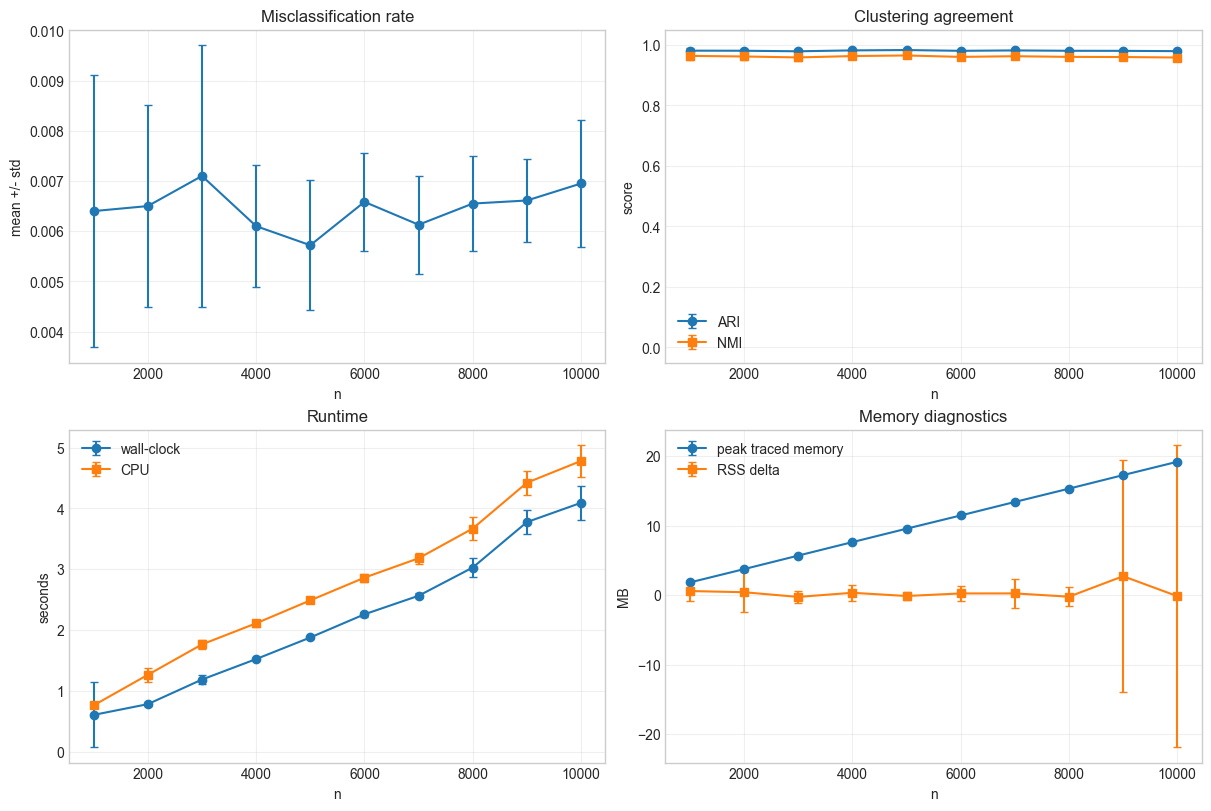

WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/메인 실험/results/EXP-20260426-002_nonuniform_hsbm_large_n_1000_to_10000_zhou_laplacian/EXP-20260426-002_nonuniform_hsbm_large_n_1000_to_10000_zhou_laplacian_summary.png')

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
x = summary["n"].to_numpy()

axes[0, 0].errorbar(
    x,
    summary["misclassification_mean"],
    yerr=summary["misclassification_std"].fillna(0.0),
    marker="o",
    capsize=3,
)
axes[0, 0].set_title("Misclassification rate")
axes[0, 0].set_xlabel("n")
axes[0, 0].set_ylabel("mean +/- std")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].errorbar(x, summary["ari_mean"], yerr=summary["ari_std"].fillna(0.0), marker="o", capsize=3, label="ARI")
axes[0, 1].errorbar(x, summary["nmi_mean"], yerr=summary["nmi_std"].fillna(0.0), marker="s", capsize=3, label="NMI")
axes[0, 1].set_title("Clustering agreement")
axes[0, 1].set_xlabel("n")
axes[0, 1].set_ylabel("score")
axes[0, 1].set_ylim(-0.05, 1.05)
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

axes[1, 0].errorbar(x, summary["wall_clock_sec_mean"], yerr=summary["wall_clock_sec_std"].fillna(0.0), marker="o", capsize=3, label="wall-clock")
axes[1, 0].errorbar(x, summary["cpu_time_sec_mean"], yerr=summary["cpu_time_sec_std"].fillna(0.0), marker="s", capsize=3, label="CPU")
axes[1, 0].set_title("Runtime")
axes[1, 0].set_xlabel("n")
axes[1, 0].set_ylabel("seconds")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

axes[1, 1].errorbar(
    x,
    summary["peak_traced_memory_mb_mean"],
    yerr=summary["peak_traced_memory_mb_std"].fillna(0.0),
    marker="o",
    capsize=3,
    label="peak traced memory",
)
if summary["rss_delta_mb_mean"].notna().any():
    axes[1, 1].errorbar(
        x,
        summary["rss_delta_mb_mean"],
        yerr=summary["rss_delta_mb_std"].fillna(0.0),
        marker="s",
        capsize=3,
        label="RSS delta",
    )
axes[1, 1].set_title("Memory diagnostics")
axes[1, 1].set_xlabel("n") 
axes[1, 1].set_ylabel("MB")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

fig_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_summary.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()

fig_path

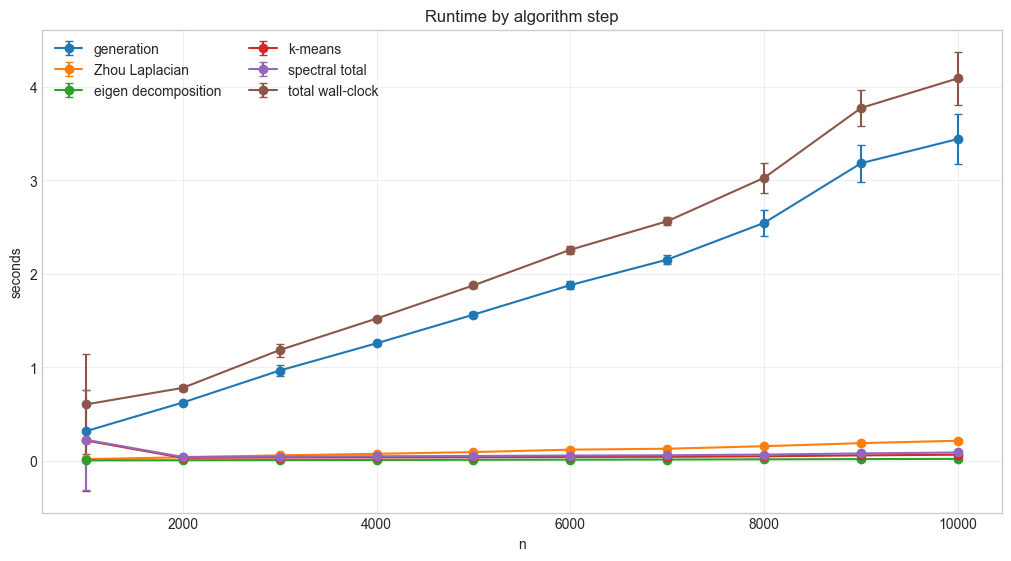

WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/메인 실험/results/EXP-20260426-002_nonuniform_hsbm_large_n_1000_to_10000_zhou_laplacian/EXP-20260426-002_nonuniform_hsbm_large_n_1000_to_10000_zhou_laplacian_runtime_breakdown.png')

In [16]:
x = summary["n"].to_numpy()

runtime_series = [
    ("generation_wall_sec", "generation"),
    ("zhou_laplacian_wall_sec", "Zhou Laplacian"),
    ("eigen_decomposition_wall_sec", "eigen decomposition"),
    ("kmeans_wall_sec", "k-means"),
    ("spectral_clustering_wall_sec", "spectral total"),
    ("wall_clock_sec", "total wall-clock"),
]

fig, ax = plt.subplots(figsize=(10, 5.5), constrained_layout=True)
for col, label in runtime_series:
    mean_col = f"{col}_mean"
    std_col = f"{col}_std"
    if mean_col not in summary.columns:
        continue
    ax.errorbar(
        x,
        summary[mean_col],
        yerr=summary[std_col].fillna(0.0) if std_col in summary.columns else None,
        marker="o",
        capsize=3,
        label=label,
    )

ax.set_title("Runtime by algorithm step")
ax.set_xlabel("n")
ax.set_ylabel("seconds")
ax.grid(alpha=0.3)
ax.legend(ncols=2)

runtime_breakdown_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_runtime_breakdown.png"
fig.savefig(runtime_breakdown_path, dpi=180, bbox_inches="tight")
plt.show()

runtime_breakdown_path

## Optional: add a larger n

Uncomment and run this cell to extend the sweep. The summary cell above will need the new frame name added to its `frames` list unless you append it manually.

In [17]:
# df_n12000 = run_n_experiment(12000)